In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Add CSV To Air Polution

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Load data
df = pd.read_csv('/content/drive/MyDrive/TUGAS SEMESTER 6/Jaringan Syaraf Tiruan/LSTM/LSTM-Multivariate_pollution.csv')
print(df.head())

                  date  pollution  dew  temp   press wnd_dir  wnd_spd  snow  \
0  2010-01-02 00:00:00      129.0  -16  -4.0  1020.0      SE     1.79     0   
1  2010-01-02 01:00:00      148.0  -15  -4.0  1020.0      SE     2.68     0   
2  2010-01-02 02:00:00      159.0  -11  -5.0  1021.0      SE     3.57     0   
3  2010-01-02 03:00:00      181.0   -7  -5.0  1022.0      SE     5.36     1   
4  2010-01-02 04:00:00      138.0   -7  -5.0  1022.0      SE     6.25     2   

   rain  
0     0  
1     0  
2     0  
3     0  
4     0  


In [3]:
# @title Praproses Data
# Drop kolom waktu jika tidak perlu
df.drop('date', axis=1, inplace=True)

# Ganti nilai NA
df.ffill(inplace=True)

# Buang kolom non-numerik (objek/string)
df_numeric = df.select_dtypes(include=[np.number])

# Normalisasi data numerik saja
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df_numeric)


# Fungsi untuk mengubah menjadi bentuk supervised learning
def create_dataset(data, n_steps=1):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i + n_steps, :])
        y.append(data[i + n_steps, 0])  # Target: kolom pertama (misalnya polusi)
    return np.array(X), np.array(y)

# Parameter
n_steps = 3  # gunakan 3 data sebelumnya untuk prediksi selanjutnya
X, y = create_dataset(scaled, n_steps)

# Split train dan test
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

Buat Model LSTM(Reggresion)

In [4]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, activation='relu', input_shape=(X.shape[1], X.shape[2])))
model.add(Dropout(0.2))  # Optional: mengurangi overfitting

model.add(LSTM(30, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(1))  # output layer
model.compile(optimizer='adam', loss='mse')

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 3, 50)          │        11,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30)             │         9,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,351 (83.40 KB)

 Trainable params: 21,351 (83.40 KB)

 Non-trainable params: 0 (0.00 B)

Latih Model

In [5]:
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.0040 - val_loss: 0.0011
Epoch 2/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0013 - val_loss: 6.5506e-04
Epoch 3/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 0.0011 - val_loss: 6.2109e-04
Epoch 4/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0011 - val_loss: 6.2924e-04
Epoch 5/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0010 - val_loss: 6.3865e-04
Epoch 6/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 9.2095e-04 - val_loss: 6.0838e-04
Epoch 7/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 9.6833e-04 - val_loss: 5.7501e-04
Epoch 8/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 8.9730e-04 - val_loss: 5.8845e-04
Epoch 9/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 8.7987e-04 - val_loss: 6.4077e-04
Epoch 10/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 9.2954e-04 - val_loss: 5.9717e-04
Epoch 11/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step -

Evaluasi dan Plot Hasil

274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


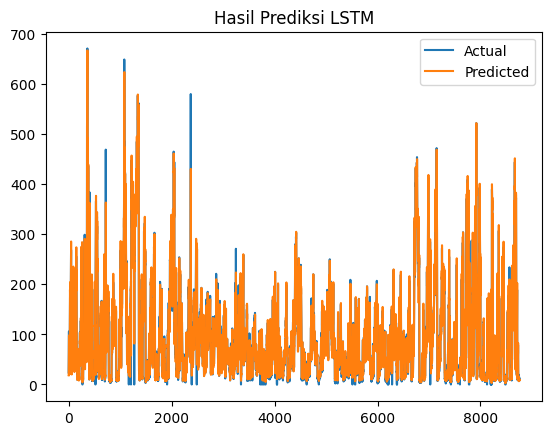

In [6]:
# Prediksi
y_pred = model.predict(X_test)

# Inverse transform jika ingin hasil asli (opsional)
y_pred_rescaled = scaler.inverse_transform(np.concatenate((y_pred, X_test[:, -1, 1:]), axis=1))[:, 0]
y_test_rescaled = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), X_test[:, -1, 1:]), axis=1))[:, 0]

# Plot
plt.plot(y_test_rescaled, label='Actual')
plt.plot(y_pred_rescaled, label='Predicted')
plt.title('Hasil Prediksi LSTM')
plt.legend()
plt.show()
